In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict



c:\Users\harsh\PROJECTS\LangGraph\agentic\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
class BatmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb:float
    bndry_percent:float

    summary: str

In [15]:
def sr_calculator(state:BatmanState):
    balls=state['balls']
    runs=state['runs']
    sr=(runs/balls)*100.00
    # state['sr']=round(sr,2)
    return {'sr':sr}

In [ ]:
def bpb_calculator(state:BatmanState) :
    balls=state['balls']
    fours=state['fours']
    sixes=state['sixes']
    bpb=balls/(fours+sixes)
    # state['bpb']=round(bpb,2)
    return {'bpb':bpb}# partial updates always 





In [ ]:
def bndry_percent_calculator(state:BatmanState) -> BatmanState:
    bndry_percent=(state['runs']/(state['fours']*4+state['sixes']*6))*100
    # state['bndry_percent']=round(bndry_percent,2)
    return {'bndry_percent':bndry_percent}

In [18]:
def summary(state:BatmanState) -> BatmanState:
    summary=f"""
Strike rate -{state['sr']},
Balls per boundry -{state['bpb']},
Boundry Percentage-{state['bndry_percent']}
"""
    return {'summary':summary}


In [19]:
graph=StateGraph(BatmanState)
graph.add_node('show_SR',sr_calculator)
graph.add_node('show_BPB',bpb_calculator)
graph.add_node('show_BNDRUY_PERCENT',bndry_percent_calculator)
graph.add_node('show_summary',summary)

graph.add_edge(START,'show_SR')
graph.add_edge(START,'show_BPB')
graph.add_edge(START,'show_BNDRUY_PERCENT')



graph.add_edge('show_SR','show_summary')
graph.add_edge('show_BPB','show_summary')
graph.add_edge('show_BNDRUY_PERCENT','show_summary')

graph.add_edge('show_summary',END)

workflow=graph.compile()




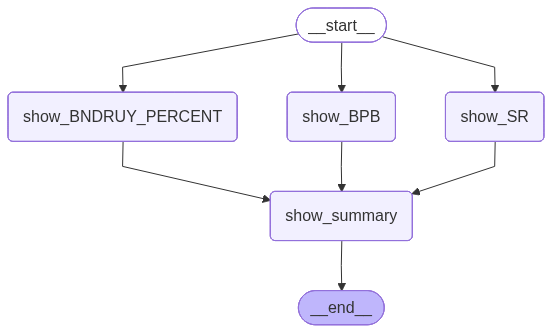

In [20]:
workflow

In [24]:
intial_state={
    'runs':100,
    'balls':50,
    'fours':4,
    'sixes':6
}
final_state=workflow.invoke(intial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 4, 'sixes': 6, 'sr': 200.0, 'bpb': 5.0, 'bndry_percent': 192.30769230769232}
